# 11 — Detailed Retriever Evaluation Pipeline

**Input:**
- `data/processed/books.csv` (or clean books CSV configured in `.env`)
- `data/eval/qrels.json` (ground-truth relevance judgments)
- All model indexes (`models/`, `data/chroma_db/`)

**Goal:**
Evaluate all five retriever pipelines across standard Information Retrieval metrics, visualize performance, and inspect sample queries with book title and description mappings instead of raw ISBNs.

**Evaluated Retrievers:**
1. TF-IDF
2. BM25
3. Dense (ChromaDB + BGE-small)
4. Hybrid RRF (BM25 + Dense)
5. Reranking (Dense + Cross-Encoder / Jina API)

## 0. Setup and Configuration

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import warnings
warnings.filterwarnings('ignore')

from src.config.settings import get_settings
from src.pipelines.evaluate_retrievers import load_dataframe, load_qrels
from src.retrieval.tfidf_retriever import TFIDFRetriever
from src.retrieval.bm25_retriever import BM25Retriever
from src.retrieval.dense_retriever import DenseRetriever
from src.retrieval.hybrid_rrf_retriever import HybridRRFRetriever
from src.retrieval.rerank_retriever import RerankRetriever
from src.evaluation.metrics import precision_at_k, recall_at_k, mrr, ndcg_at_k, map_score

# Matplotlib settings for rich aesthetics
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F9F9F9',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

MODEL_COLORS = {
    'TF-IDF'   : '#6B8CBA',
    'BM25'     : '#F4A261',
    'Dense'    : '#2A9D8F',
    'Hybrid'   : '#E76F51',
    'Reranking': '#8338EC',
}

# 1. Load settings and books dataset
settings = get_settings()
df = load_dataframe(settings)
print(f"Loaded books dataset: {len(df):,} books")

# 2. Load qrels
qrels = load_qrels(settings.eval_output_path / "qrels.json")
print(f"Loaded ground-truth qrels: {len(qrels)} queries")

Loaded books dataset: 100 books
Loaded ground-truth qrels: 382 queries


In [2]:
# 3. Load all 5 retrievers
print("Loading retrievers...")
tfidf = TFIDFRetriever.load(
    model_path=Path(settings.tfidf_model_path),
    matrix_path=Path(settings.tfidf_matrix_path),
    df=df,
)
print("  TF-IDF loaded [OK]")

bm25 = BM25Retriever.load(
    index_path=Path(settings.bm25_index_path),
    df=df,
)
print("  BM25 loaded [OK]")

dense = DenseRetriever.load(
    chroma_path=Path(settings.chroma_path),
    embedding_model=settings.embedding_model,
    collection_name=settings.chroma_collection_name,
)
print("  Dense (ChromaDB) loaded [OK]")

hybrid = HybridRRFRetriever(
    bm25_retriever=bm25,
    dense_retriever=dense,
    candidate_pool=settings.hybrid_candidate_pool,
    rrf_k=settings.rrf_k,
)
print("  Hybrid RRF loaded [OK]")

rerank = RerankRetriever(
    dense_retriever=dense,
    rerank_model=settings.jina_rerank_model if settings.rerank_use_api else settings.rerank_model,
    candidate_pool=settings.rerank_candidate_pool,
    use_api=settings.rerank_use_api,
    jina_api_key=settings.jina_api_key,
    rerank_workers=settings.rerank_workers,
)
print("  Reranking loaded [OK]")

retrievers = {
    'tfidf': tfidf,
    'bm25': bm25,
    'dense': dense,
    'hybrid_rrf': hybrid,
    'rerank': rerank
}

Loading retrievers...
  TF-IDF loaded [OK]
  BM25 loaded [OK]
  Dense (ChromaDB) loaded [OK]
  Hybrid RRF loaded [OK]
  Reranking loaded [OK]


## 1. Caching Search Results
To avoid re-running all queries in every single metric cell, we will cache the search results and timing (latency) in memory first.

In [3]:
print(f"Running retrieval on {len(qrels)} queries...")
retrieved_results = {name: [] for name in retrievers.keys()}
latencies = {name: [] for name in retrievers.keys()}

for i, qrel in enumerate(qrels):
    if (i + 1) % 10 == 0 or i == 0 or i == len(qrels) - 1:
        print(f"  Processing query {i + 1}/{len(qrels)}: '{qrel.query[:40]}...'")
    for name, retriever in retrievers.items():
        t_start = time.perf_counter()
        results = retriever.search(qrel.query, top_k=10)
        elapsed_ms = (time.perf_counter() - t_start) * 1000
        
        retrieved_results[name].append([res.isbn13 for res in results])
        latencies[name].append(elapsed_ms)

print("\nRetrieval caching finished! Ready for metric calculations.")

Running retrieval on 382 queries...
  Processing query 1/382: 'World Cup statistics...'


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5349.50it/s]


  Processing query 10/382: 'murder mystery...'
  Processing query 20/382: 'detective story with a romantic twist...'
  Processing query 30/382: 'a young woman believes she is a murderer...'
  Processing query 40/382: 'science fiction short stories...'
  Processing query 50/382: 'search for a missing prince...'
  Processing query 60/382: 'an epic tale of family conflict and adve...'
  Processing query 70/382: 'children's fantasy...'
  Processing query 80/382: 'forbidden witchcraft in a school setting...'
  Processing query 90/382: 'a classic tale of friendship, courage, a...'
  Processing query 100/382: 'Texas thriller...'
  Processing query 110/382: 'creativity in the workplace...'
  Processing query 120/382: 'a battle for power between ancient gods ...'
  Processing query 130/382: 'Chinese history...'
  Processing query 140/382: 'AS and A-Level sociology guide...'
  Processing query 150/382: 'the concluding volume of a legendary fan...'
  Processing query 160/382: 'murder mystery thri

## 2. Metric Computation Cells
In the following cells, we calculate the average score of each metric for all retrievers.

### Metric: Precision@5

In [4]:
p5_scores = {}
for name in retrievers.keys():
    scores = [precision_at_k(ret, set(qrel.relevant_isbns), k=5) 
              for ret, qrel in zip(retrieved_results[name], qrels)]
    p5_scores[name] = np.mean(scores)

print("=" * 40)
print(f"Mean Precision@5 (n={len(qrels)} queries)")
print("=" * 40)
for name, val in p5_scores.items():
    print(f"{name:<12}: {val:.4f}")
print("=" * 40)

Mean Precision@5 (n=382 queries)
tfidf       : 0.2445
bm25        : 0.2414
dense       : 0.4021
hybrid_rrf  : 0.3099
rerank      : 0.4105


### Metric: Precision@10

In [5]:
p10_scores = {}
for name in retrievers.keys():
    scores = [precision_at_k(ret, set(qrel.relevant_isbns), k=10) 
              for ret, qrel in zip(retrieved_results[name], qrels)]
    p10_scores[name] = np.mean(scores)

print("=" * 40)
print(f"Mean Precision@10 (n={len(qrels)} queries)")
print("=" * 40)
for name, val in p10_scores.items():
    print(f"{name:<12}: {val:.4f}")
print("=" * 40)

Mean Precision@10 (n=382 queries)
tfidf       : 0.1665
bm25        : 0.1668
dense       : 0.3113
hybrid_rrf  : 0.2555
rerank      : 0.3199


### Metric: Recall@5

In [6]:
r5_scores = {}
for name in retrievers.keys():
    scores = [recall_at_k(ret, set(qrel.relevant_isbns), k=5) 
              for ret, qrel in zip(retrieved_results[name], qrels)]
    r5_scores[name] = np.mean(scores)

print("=" * 40)
print(f"Mean Recall@5 (n={len(qrels)} queries)")
print("=" * 40)
for name, val in r5_scores.items():
    print(f"{name:<12}: {val:.4f}")
print("=" * 40)

Mean Recall@5 (n=382 queries)
tfidf       : 0.3354
bm25        : 0.3536
dense       : 0.5078
hybrid_rrf  : 0.4187
rerank      : 0.5272


### Metric: Recall@10

In [7]:
r10_scores = {}
for name in retrievers.keys():
    scores = [recall_at_k(ret, set(qrel.relevant_isbns), k=10) 
              for ret, qrel in zip(retrieved_results[name], qrels)]
    r10_scores[name] = np.mean(scores)

print("=" * 40)
print(f"Mean Recall@10 (n={len(qrels)} queries)")
print("=" * 40)
for name, val in r10_scores.items():
    print(f"{name:<12}: {val:.4f}")
print("=" * 40)

Mean Recall@10 (n=382 queries)
tfidf       : 0.4017
bm25        : 0.4155
dense       : 0.6718
hybrid_rrf  : 0.5879
rerank      : 0.7005


### Metric: Mean Reciprocal Rank (MRR)

In [8]:
mrr_scores = {}
for name in retrievers.keys():
    scores = [mrr(ret, set(qrel.relevant_isbns)) 
              for ret, qrel in zip(retrieved_results[name], qrels)]
    mrr_scores[name] = np.mean(scores)

print("=" * 40)
print(f"Mean Reciprocal Rank (MRR) (n={len(qrels)} queries)")
print("=" * 40)
for name, val in mrr_scores.items():
    print(f"{name:<12}: {val:.4f}")
print("=" * 40)

Mean Reciprocal Rank (MRR) (n=382 queries)
tfidf       : 0.6079
bm25        : 0.6631
dense       : 0.7981
hybrid_rrf  : 0.7195
rerank      : 0.7976


### Metric: NDCG@10

In [9]:
ndcg_scores = {}
for name in retrievers.keys():
    scores = [ndcg_at_k(ret, set(qrel.relevant_isbns), k=10) 
              for ret, qrel in zip(retrieved_results[name], qrels)]
    ndcg_scores[name] = np.mean(scores)

print("=" * 40)
print(f"Mean NDCG@10 (n={len(qrels)} queries)")
print("=" * 40)
for name, val in ndcg_scores.items():
    print(f"{name:<12}: {val:.4f}")
print("=" * 40)

Mean NDCG@10 (n=382 queries)
tfidf       : 0.4101
bm25        : 0.4408
dense       : 0.6544
hybrid_rrf  : 0.5593
rerank      : 0.6735


### Metric: Mean Average Precision (MAP)

In [10]:
map_scores = {}
for name in retrievers.keys():
    scores = [map_score(ret, set(qrel.relevant_isbns)) 
              for ret, qrel in zip(retrieved_results[name], qrels)]
    map_scores[name] = np.mean(scores)

print("=" * 40)
print(f"Mean Average Precision (MAP) (n={len(qrels)} queries)")
print("=" * 40)
for name, val in map_scores.items():
    print(f"{name:<12}: {val:.4f}")
print("=" * 40)

Mean Average Precision (MAP) (n=382 queries)
tfidf       : 0.2938
bm25        : 0.3239
dense       : 0.4997
hybrid_rrf  : 0.4080
rerank      : 0.5210


## 3. Metrics Visualizations

Retriever      P@5     P@10      R@5     R@10      MRR  NDCG@10      MAP
   TF-IDF 0.244503 0.166492 0.335371 0.401745 0.607928 0.410088 0.293850
     BM25 0.241361 0.166754 0.353639 0.415473 0.663072 0.440811 0.323888
    Dense 0.402094 0.311257 0.507797 0.671753 0.798129 0.654447 0.499716
   Hybrid 0.309948 0.255497 0.418725 0.587943 0.719485 0.559347 0.407990
Reranking 0.410471 0.319895 0.527246 0.700504 0.797576 0.673497 0.521022


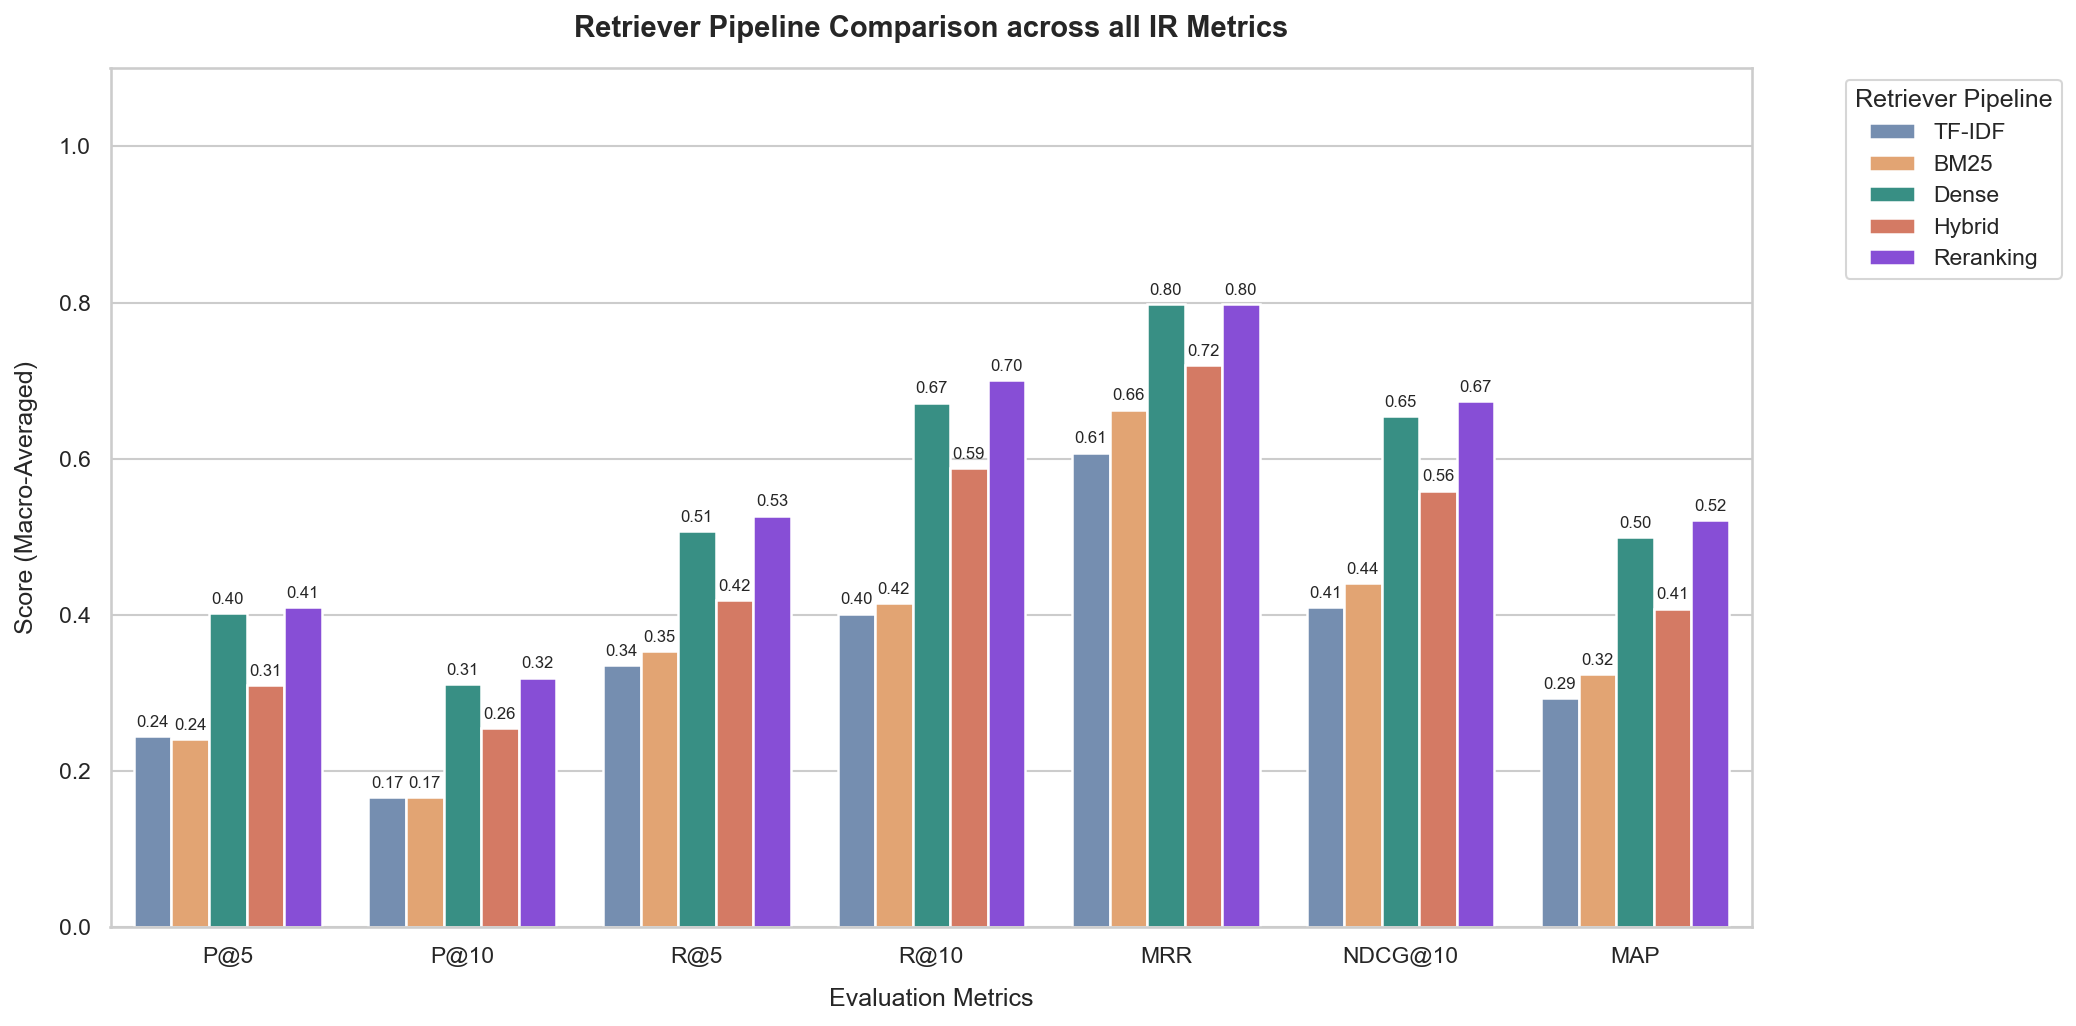

In [11]:
# Gather all metrics into a pandas DataFrame
metrics_summary = []
retriever_labels = {
    'tfidf': 'TF-IDF',
    'bm25': 'BM25',
    'dense': 'Dense',
    'hybrid_rrf': 'Hybrid',
    'rerank': 'Reranking'
}

for name in retrievers.keys():
    metrics_summary.append({
        'Retriever': retriever_labels[name],
        'P@5': p5_scores[name],
        'P@10': p10_scores[name],
        'R@5': r5_scores[name],
        'R@10': r10_scores[name],
        'MRR': mrr_scores[name],
        'NDCG@10': ndcg_scores[name],
        'MAP': map_scores[name]
    })

df_metrics = pd.DataFrame(metrics_summary)
print(df_metrics.to_string(index=False))

# Melt DataFrame for seaborn grouped barplot
df_melted = df_metrics.melt(id_vars='Retriever', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    data=df_melted,
    x='Metric',
    y='Score',
    hue='Retriever',
    palette=[MODEL_COLORS[retriever_labels[name]] for name in retrievers.keys()],
    edgecolor='white',
    linewidth=1.2
)

# Add scores on top of bars
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.2f}', 
                    xy=(p.get_x() + p.get_width() / 2, h),
                    xytext=(0, 3), 
                    textcoords='offset points', 
                    ha='center', va='bottom', fontsize=8)

plt.title('Retriever Pipeline Comparison across all IR Metrics', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Evaluation Metrics', fontsize=12, labelpad=10)
plt.ylabel('Score (Macro-Averaged)', fontsize=12, labelpad=10)
plt.ylim(0, 1.1)
plt.legend(title='Retriever Pipeline', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the figure
figures_dir = Path("reports/figures")
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "retriever_metrics_comparison.png", bbox_inches='tight', dpi=150)
plt.show()

## 4. Qualitative Analysis & Visual Mapping
Let's visualize the actual **book titles** and **descriptions** corresponding to the ground-truth relevant books and the retriever predictions.

In [16]:
# Helper to look up title and description from books DataFrame
def get_book_details(isbn: str) -> tuple[str, str]:
    matches = df[df['isbn13'] == str(isbn)]
    if not matches.empty:
        title = matches.iloc[0]['title']
        desc = matches.iloc[0]['description']
        return str(title), str(desc)
    return "Unknown Book", "No description available in dataset."

# Pick 3 interesting queries with non-empty ground truth
sample_queries = []
for q in qrels:
    if len(q.relevant_isbns) >= 2:
        sample_queries.append(q)
    if len(sample_queries) == 3:
        break

# Fallback in case there are not enough queries with >= 2 relevant books
if len(sample_queries) < 3:
    sample_queries = qrels[:3]

for idx, qrel in enumerate(sample_queries):
    print(f"\n{'='*95}")
    print(f"QUERY #{idx + 1}: \"{qrel.query}\"")
    print(f"{'='*95}")
    
    # 1. Ground Truth Details
    print("\n--- GROUND TRUTH RELEVANT BOOKS ---")
    for g_isbn in qrel.relevant_isbns:
        g_title, g_desc = get_book_details(g_isbn)
        print(f"  * ISBN: {g_isbn} | Title: {g_title}")
        print(f"    Description: {g_desc[:150]}\n{g_desc[150:300]}\n{g_desc[300:450]}\n{g_desc[450:600]}\n{g_desc[600:750]}\n{g_desc[750:900]}")
        print("-" * 70)
        
    # 2. Retriever Predictions Details
    print("\n--- RETRIEVER PREDICTIONS ---")
    for name, retriever in retrievers.items():
        print(f"\n[{retriever_labels[name]} Retriever]")
        # Find index of this query in cached results
        q_idx = qrels.index(qrel)
        pred_isbns = retrieved_results[name][q_idx][:5]  # Top 5
        
        for rank, p_isbn in enumerate(pred_isbns, start=1):
            p_title, p_desc = get_book_details(p_isbn)
            is_hit = p_isbn in qrel.relevant_isbns
            hit_str = "[HIT]" if is_hit else "[MISS]"
            print(f"    Rank {rank} | {hit_str} | ISBN: {p_isbn} | Title: {p_title}")
            print(f"    Description: {p_desc[:150]}\n{p_desc[150:300]}\n{p_desc[300:450]}\n{p_desc[450:600]}\n{p_desc[600:750]}\n{p_desc[750:900]}")


QUERY #1: "father-daughter relationship"

--- GROUND TRUTH RELEVANT BOOKS ---
  * ISBN: 9780002240802 | Title: The Last Thing He Wanted
    Description: Journalist Elena McMahon watches her evasive, gruff father's life ebbing away before her. A desire to understand hm impels her to do his bidding, to g
o into a situation in Central America, knowing neither what to expect, what to ask or what to define as achievement.




----------------------------------------------------------------------
  * ISBN: 9780007170760 | Title: Wild Swans
    Description: A New Edition Of One Of The Best-Selling And Best-Loved Books Of Recent Years, With A New Introduction By The Author. The Publication Of Wild Swans In
 1991 Was A Worldwide Phenomenon. Not Only Did It Become The Best-Selling Non-Fiction Book In British Publishing History, With Sales Of Well Over Two 
Million, It Was Received With Unanimous Critical Acclaim, And Was Named The Winner Of The 1992 Ncr Book Award And The 1993 British Book Of T

## 5. Hybrid Evaluation with Weights 

Caching candidate search results for BM25 and Dense...
  Fetching candidates for query 1/382...
  Fetching candidates for query 50/382...
  Fetching candidates for query 100/382...
  Fetching candidates for query 150/382...
  Fetching candidates for query 200/382...
  Fetching candidates for query 250/382...
  Fetching candidates for query 300/382...
  Fetching candidates for query 350/382...
  Fetching candidates for query 382/382...

Evaluating weight combinations...
Weight Config             | P@5      | P@10     | R@5      | R@10     | MRR      | NDCG@10  | MAP     
BM25:0.8 / Dense:0.2      | 0.2812   | 0.2050    | 0.3950   | 0.4850    | 0.6985   | 0.4987     | 0.3699
BM25:0.7 / Dense:0.3      | 0.2874   | 0.2052    | 0.3992   | 0.4856    | 0.7072   | 0.5021     | 0.3731
BM25:0.6 / Dense:0.4      | 0.2953   | 0.2055    | 0.4062   | 0.4857    | 0.7103   | 0.5047     | 0.3761
BM25:0.5 / Dense:0.5      | 0.3099   | 0.2555    | 0.4187   | 0.5879    | 0.7195   | 0.5593     | 0.4080
BM2

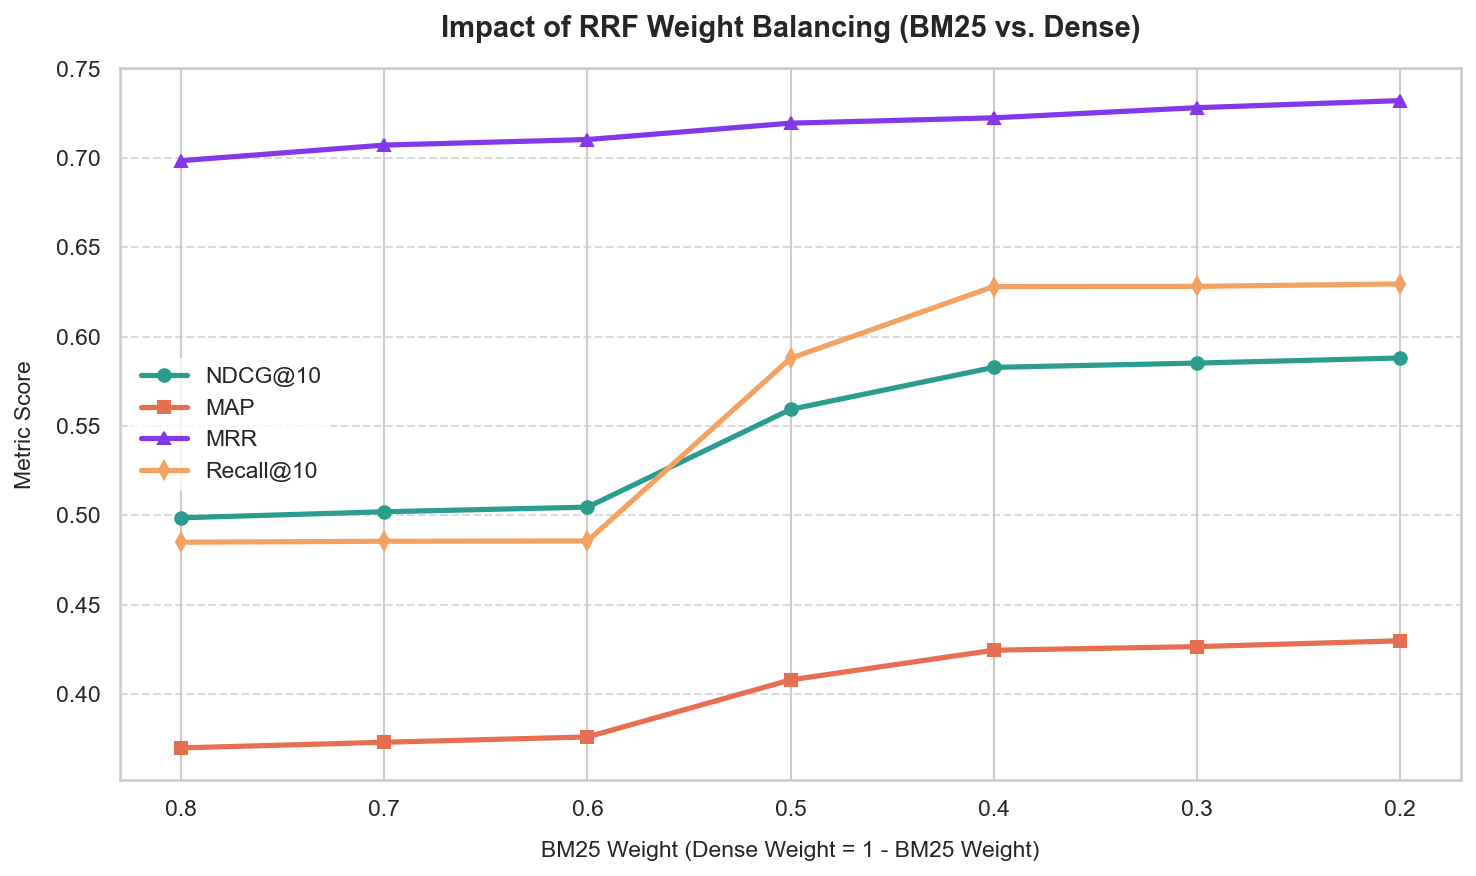

In [17]:
weights = [[0.8, 0.2], [0.7, 0.3], [0.6, 0.4], [0.5, 0.5], [0.4, 0.6], [0.3, 0.7], [0.2, 0.8]]

# 1. Retrieve candidates pool once to run RRF in-memory extremely fast
print("Caching candidate search results for BM25 and Dense...")
bm25_candidate_runs = []
dense_candidate_runs = []
for i, qrel in enumerate(qrels):
    if (i + 1) % 50 == 0 or i == 0 or i == len(qrels) - 1:
        print(f"  Fetching candidates for query {i+1}/{len(qrels)}...")
    bm25_candidate_runs.append(bm25.search(qrel.query, top_k=settings.hybrid_candidate_pool))
    dense_candidate_runs.append(dense.search(qrel.query, top_k=settings.hybrid_candidate_pool))

from collections import defaultdict
def fuse_rrf(bm25_results, dense_results, w_bm25, w_dense, k=60, top_k=10):
    rrf_scores = defaultdict(float)
    for r in bm25_results:
        rrf_scores[r.isbn13] += w_bm25 * (1.0 / (k + r.rank))
    for r in dense_results:
        rrf_scores[r.isbn13] += w_dense * (1.0 / (k + r.rank))
    sorted_items = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return [isbn for isbn, _ in sorted_items]

results_data = []
print("\nEvaluating weight combinations...")
for w_bm25, w_dense in weights:
    label = f"BM25:{w_bm25:.1f} / Dense:{w_dense:.1f}"
    
    # Run fusion on cached candidates
    fused_results = []
    for bm25_res, dense_res in zip(bm25_candidate_runs, dense_candidate_runs):
        fused_isbns = fuse_rrf(bm25_res, dense_res, w_bm25, w_dense, k=settings.rrf_k, top_k=10)
        fused_results.append(fused_isbns)
        
    # Compute metrics
    p5 = np.mean([precision_at_k(ret, set(qrel.relevant_isbns), k=5) for ret, qrel in zip(fused_results, qrels)])
    p10 = np.mean([precision_at_k(ret, set(qrel.relevant_isbns), k=10) for ret, qrel in zip(fused_results, qrels)])
    r5 = np.mean([recall_at_k(ret, set(qrel.relevant_isbns), k=5) for ret, qrel in zip(fused_results, qrels)])
    r10 = np.mean([recall_at_k(ret, set(qrel.relevant_isbns), k=10) for ret, qrel in zip(fused_results, qrels)])
    mrr_val = np.mean([mrr(ret, set(qrel.relevant_isbns)) for ret, qrel in zip(fused_results, qrels)])
    ndcg10 = np.mean([ndcg_at_k(ret, set(qrel.relevant_isbns), k=10) for ret, qrel in zip(fused_results, qrels)])
    map_val = np.mean([map_score(ret, set(qrel.relevant_isbns)) for ret, qrel in zip(fused_results, qrels)])
    
    results_data.append({
        'Weight Configuration': label,
        'BM25 Weight': w_bm25,
        'Dense Weight': w_dense,
        'P@5': p5,
        'P@10': p10,
        'R@5': r5,
        'R@10': r10,
        'MRR': mrr_val,
        'NDCG@10': ndcg10,
        'MAP': map_val
    })

# Format and display DataFrame
df_results = pd.DataFrame(results_data)
print("=" * 105)
print(f"{'Weight Config':<25} | {'P@5':<8} | {'P@10':<8} | {'R@5':<8} | {'R@10':<8} | {'MRR':<8} | {'NDCG@10':<8} | {'MAP':<8}")
print("=" * 105)
for idx, row in df_results.iterrows():
    print(f"{row['Weight Configuration']:<25} | {row['P@5']:.4f}   | {row['P@10']:.4f}    | {row['R@5']:.4f}   | {row['R@10']:.4f}    | {row['MRR']:.4f}   | {row['NDCG@10']:.4f}     | {row['MAP']:.4f}")
print("=" * 105)

# Matplotlib visualization of metrics with curated color palettes and rich aesthetics
plt.figure(figsize=(10, 6))
plt.plot(df_results['BM25 Weight'], df_results['NDCG@10'], marker='o', linewidth=2.5, color='#2A9D8F', label='NDCG@10')
plt.plot(df_results['BM25 Weight'], df_results['MAP'], marker='s', linewidth=2.5, color='#E76F51', label='MAP')
plt.plot(df_results['BM25 Weight'], df_results['MRR'], marker='^', linewidth=2.5, color='#8338EC', label='MRR')
plt.plot(df_results['BM25 Weight'], df_results['R@10'], marker='d', linewidth=2.5, color='#F4A261', label='Recall@10')

plt.title('Impact of RRF Weight Balancing (BM25 vs. Dense)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('BM25 Weight (Dense Weight = 1 - BM25 Weight)', fontsize=11, labelpad=10)
plt.ylabel('Metric Score', fontsize=11, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().invert_xaxis()
plt.xticks(df_results['BM25 Weight'], [f"{w:.1f}" for w in df_results['BM25 Weight']])
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()
